# U-Net Binary Leaf Segmentation + Overlap Separation

**Dua tahap:**  
1. **Binary U-Net** — segmentasi daun vs background (daun = 1, background = 0)  
2. **Watershed Post-Processing** — pisah daun yang saling tumpuk dari binary mask  

Tidak ada perubahan pada base code. Semua logika inline di notebook ini.

---

| Item | Value |
|------|-------|
| Repo | `https://github.com/HaikalFK/segmentasi-unet.git` |
| Branch | `train_config` |
| Dataset | Plant Phenotyping (Kaggle) |
| Model | U-Net original (2 class: bg + leaf) |
| Runtime | **GPU** (T4, V100, A100) |

---
## 0. Setup Environment

In [1]:
# Verify GPU
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA: True
Device: Tesla T4


In [2]:
# Clone repo
import os, shutil
from pathlib import Path

REPO_URL = 'https://github.com/HaikalFK/segmentasi-unet.git'
REPO_DIR = Path('/content/segmentasi-unet')

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)
!git clone -b train_config {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
print(f'CWD: {os.getcwd()}')

Cloning into '/content/segmentasi-unet'...
remote: Enumerating objects: 197, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 197 (delta 86), reused 159 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (197/197), 4.95 MiB | 10.12 MiB/s, done.
Resolving deltas: 100% (86/86), done.
/content/segmentasi-unet
CWD: /content/segmentasi-unet


In [3]:
# Dependencies
!pip install --quiet --upgrade pip
!pip install --quiet -r requirements.txt
!pip install --quiet opencv-python-headless

from utils.data_loading import BasicDataset
from unet import UNet
print('All imports OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.7 MB/s eta 0:00:00a 0:00:01
All imports OK


In [ ]:
# Download dataset
!python data/download_dataset.py

Plant Phenotyping Dataset Downloader



---
## 1. Binary Dataset Wrapper

Mengubah mask multi-class (0–27) menjadi **binary** (0 = background, 1 = daun).  
Semua pixel > 0 di-mapping ke 1.

In [5]:
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from collections import OrderedDict

class BinaryLeafDataset(Dataset):
    """Wrapper yang mengubah mask multi-class jadi binary."""
    def __init__(self, img_dir, mask_dir, scale=0.5, target_size=(256, 256)):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.scale = scale
        self.target_size = target_size
        self.ids = [p.stem for p in Path(img_dir).glob('*.png')]
        print(f'Dataset: {len(self.ids)} samples, binary (bg + leaf)')

    def __len__(self):
        return len(self.ids)

    def preprocess_img(self, pil_img):
        w, h = pil_img.size
        tw, th = self.target_size
        pil_img = pil_img.resize((tw, th), Image.BICUBIC)
        img = np.asarray(pil_img)
        if img.ndim == 2:
            img = img[np.newaxis, ...]
        else:
            img = img.transpose((2, 0, 1))
        img = img / 255.0
        return img

    def preprocess_mask(self, pil_img):
        tw, th = self.target_size
        pil_img = pil_img.resize((tw, th), Image.NEAREST)
        mask = np.asarray(pil_img, dtype=np.int64)
        binary = (mask > 0).astype(np.int64)
        return binary

    def __getitem__(self, idx):
        name = self.ids[idx]
        img = Image.open(self.img_dir / f'{name}.png').convert('RGB')
        mask = Image.open(self.mask_dir / f'{name}.png')
        return {
            'image': torch.from_numpy(self.preprocess_img(img)).float(),
            'mask': torch.from_numpy(self.preprocess_mask(mask)).long(),
            'name': name,
        }

In [6]:
# Quick test
ds = BinaryLeafDataset('./data/imgs/', './data/masks/', scale=0.5, target_size=(256, 256))
sample = ds[0]
print(f'Image shape: {sample["image"].shape}')
print(f'Mask shape : {sample["mask"].shape}')
print(f'Mask unique: {torch.unique(sample["mask"]).tolist()}')
print(f'Name       : {sample["name"]}')

Dataset: 347 samples, binary (bg + leaf)
Image shape: torch.Size([3, 256, 256])
Mask shape : torch.Size([256, 256])
Mask unique: [0, 1]
Name       : ara2012_plant010


---
## 2. Loss Function (Dice + BCE)

Dice Loss membantu atasi class imbalance. Kombinasi dengan BCE untuk stabilitas.

In [ ]:
import torch.nn.functional as F
from utils.dice_score import dice_loss

def combined_loss(pred, target):
    """
    BCE + Dice Loss dengan class weighting.
    Weight = inverse frequency — foreground diberi prioritas tinggi
    untuk mencegah model collapse ke background.
    """
    # Hitung proporsi kelas dalam batch
    n_fg = (target == 1).sum().float()
    n_bg = (target == 0).sum().float()
    total = n_fg + n_bg

    # Inverse frequency weight, clamp agar tidak ekstrim
    w_fg = (total / (2 * n_fg + 1e-6)).clamp(0.3, 3.0)
    w_bg = (total / (2 * n_bg + 1e-6)).clamp(0.3, 3.0)
    weight = torch.tensor([w_bg, w_fg], device=pred.device)

    bce = F.cross_entropy(pred, target, weight=weight)
    prob = F.softmax(pred, dim=1)[:, 1]
    dice = dice_loss(prob, target.float(), multiclass=False)
    return bce + dice

---
## 3. Metrics (Binary)

IoU dan Dice untuk binary segmentation.

In [ ]:
def binary_metrics(pred_mask, true_mask, eps=1e-8):
    """pred_mask, true_mask: (B, H, W) dalam {0,1}"""
    inter = (pred_mask & true_mask).sum().float()
    union = (pred_mask | true_mask).sum().float()
    iou = inter / (union + eps)
    dice = (2 * inter) / (pred_mask.sum() + true_mask.sum() + eps)
    return iou.item(), dice.item()

---
## 4. Training Configuration

In [9]:
EPOCHS          = 100
BATCH_SIZE      = 8
LR              = 1e-5           # Sama dengan yang terbukti stabil di 22-class
VALIDATION_PCT  = 10.0
AMP             = True
IMG_SIZE        = (256, 256)
SCALE           = 0.5
PATIENCE        = 15
DELTA           = 0.005

print(f'Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, LR: {LR}, AMP: {AMP}')

Epochs: 100, Batch: 8, LR: 1e-05, AMP: True


---
## 5. Train Binary U-Net

In [10]:
import copy, os
from tqdm import tqdm
from torch import optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Model — 2 classes (background + leaf)
model = UNet(n_channels=3, n_classes=2, bilinear=False)
model = model.to(memory_format=torch.channels_last)
model.to(device)

# Dataset & loader
dataset = BinaryLeafDataset('./data/imgs/', './data/masks/', scale=SCALE, target_size=IMG_SIZE)
n_val = int(len(dataset) * VALIDATION_PCT / 100)
n_train = len(dataset) - n_val
train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))

num_workers = 0 if device.type == 'cpu' else os.cpu_count()
loader_args = dict(batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=(device.type=='cuda'))
train_loader = DataLoader(train_set, shuffle=True, **loader_args)
val_loader = DataLoader(val_set, shuffle=False, drop_last=True, **loader_args)

optimizer = optim.RMSprop(model.parameters(), lr=LR, weight_decay=1e-8, momentum=0.999, foreach=False, eps=1e-8)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, min_lr=1e-7)
scaler = torch.amp.GradScaler('cuda', enabled=AMP)

# State — best_dice di -1 supaya epoch 1 auto-save
best_dice = -1.0
best_state = None
stale_epochs = 0
global_step = 0
history = {'epoch': [], 'train_loss': [], 'val_iou': [], 'val_dice': []}

Path('checkpoints').mkdir(exist_ok=True)

print(f'Train: {n_train}  Val: {n_val}')
print('='*60)

Device: cuda
Dataset: 347 samples, binary (bg + leaf)
Train: 313  Val: 34


In [11]:
for epoch in range(1, EPOCHS + 1):
    # ── Training ──
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', unit='batch')

    for batch in pbar:
        imgs = batch['image'].to(device, dtype=torch.float32, memory_format=torch.channels_last)
        masks = batch['mask'].to(device, dtype=torch.long)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=AMP):
            pred = model(imgs)
            loss = combined_loss(pred, masks)

        # Cek NaN SEBELUM backward — skip aman, scaler tidak tersentuh
        if torch.isnan(loss) or torch.isinf(loss):
            pbar.set_postfix(loss='NaN (skip)')
            continue

        scaler.scale(loss).backward()

        # unscale_ + clip grad
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Step hanya jika gradien sehat
        if not (torch.isnan(grad_norm) or torch.isinf(grad_norm)):
            scaler.step(optimizer)
            epoch_loss += loss.item()
            global_step += 1
            pbar.set_postfix(loss=f'{loss.item():.4f}')
        else:
            # Skip step, tapi scaler harus di-update tetap
            pbar.set_postfix(loss='gradNaN (skip)')

        scaler.update()

    avg_loss = epoch_loss / max(len(train_loader), 1)

    # ── Validation ──
    model.eval()
    total_iou = 0.0
    total_dice = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Val', unit='batch', leave=False):
            imgs = batch['image'].to(device, dtype=torch.float32, memory_format=torch.channels_last)
            masks = batch['mask'].to(device, dtype=torch.long)
            with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=AMP):
                pred = model(imgs)
            pred_bin = pred.argmax(dim=1)
            iou, dice = binary_metrics(pred_bin, masks)
            total_iou += iou
            total_dice += dice

    avg_iou = total_iou / max(len(val_loader), 1)
    avg_dice = total_dice / max(len(val_loader), 1)
    scheduler.step(avg_dice)

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)
    history['val_iou'].append(avg_iou)
    history['val_dice'].append(avg_dice)

    print(f'  Loss: {avg_loss:.4f}  |  IoU: {avg_iou:.4f}  |  Dice: {avg_dice:.4f}')

    # ── Early stopping — best_dice dimulai dari -1, jadi epoch 1 otomatis tersimpan ──
    if avg_dice > best_dice + DELTA:
        best_dice = avg_dice
        best_state = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'checkpoints/best_binary.pth')
        stale_epochs = 0
        print(f'  ★ New best! Dice: {best_dice:.4f}')
    else:
        stale_epochs += 1

    if stale_epochs >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break

# Save final
if best_state is not None:
    model.load_state_dict(best_state)
    torch.save({'model': best_state, 'history': history}, 'checkpoints/binary_unet_complete.pth')
print(f'\nTraining selesai. Best Dice: {best_dice:.4f}')

Epoch 1/100: 100%|██████████| 40/40 [00:17<00:00,  2.28batch/s, loss=1.7035]


  Loss: 0.4107  |  IoU: 0.3520  |  Dice: 0.5163
  ★ New best! Dice: 0.5163


Epoch 2/100: 100%|██████████| 40/40 [00:13<00:00,  2.89batch/s, loss=0.3194]


  Loss: 0.1639  |  IoU: 0.1955  |  Dice: 0.3113


Epoch 3/100: 100%|██████████| 40/40 [00:13<00:00,  2.90batch/s, loss=0.0878]


...

  Loss: 0.0019  |  IoU: 0.0000  |  Dice: 0.0000


Epoch 21/100: 100%|██████████| 40/40 [00:12<00:00,  3.18batch/s, loss=NaN (skip)]


  Loss: 0.0161  |  IoU: 0.0000  |  Dice: 0.0000


Epoch 22/100: 100%|██████████| 40/40 [00:12<00:00,  3.22batch/s, loss=0.1027]    


  Loss: 0.0047  |  IoU: 0.0000  |  Dice: 0.0000
Early stop at epoch 22

Training selesai. Best Dice: 0.9615


---
## 6. Learning Curve

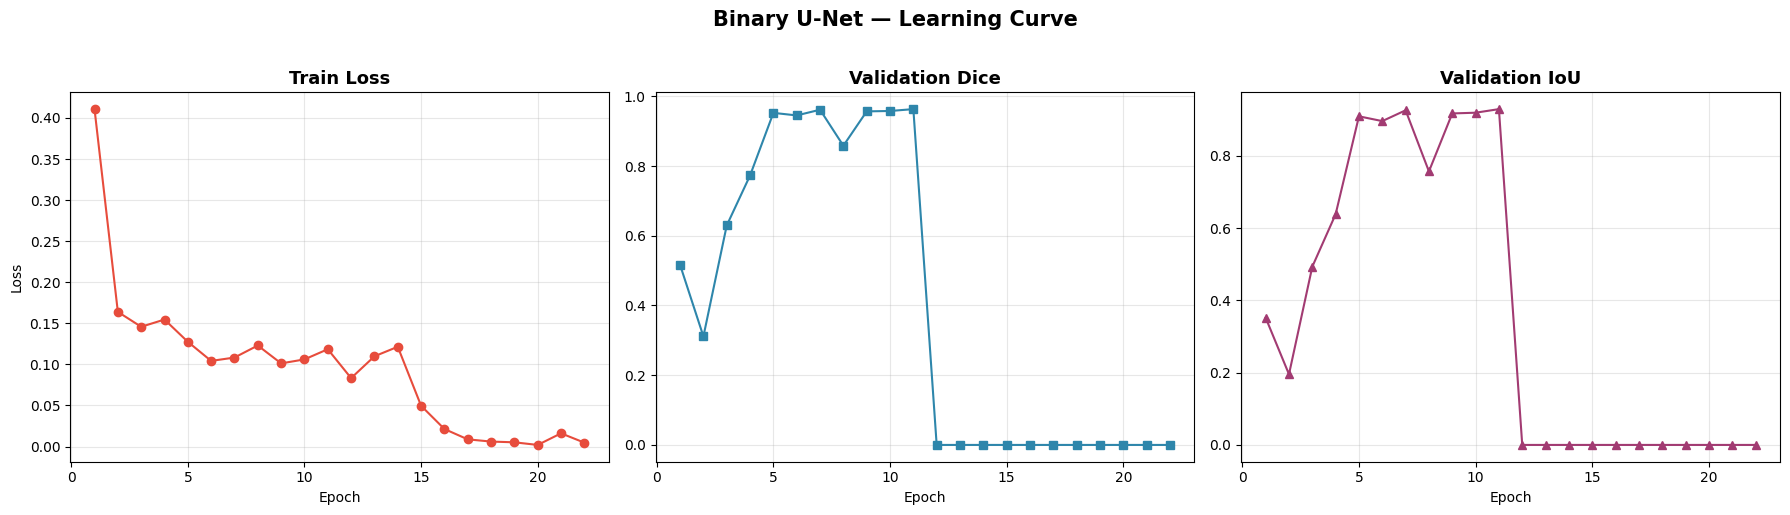

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['epoch'], history['train_loss'], 'o-', color='#E74C3C')
axes[0].set_title('Train Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['val_dice'], 's-', color='#2E86AB')
axes[1].set_title('Validation Dice', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)

axes[2].plot(history['epoch'], history['val_iou'], '^-', color='#A23B72')
axes[2].set_title('Validation IoU', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

plt.suptitle('Binary U-Net — Learning Curve', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('binary_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Evaluate on Validation Set

In [13]:
# Load best model — fallback ke file atau state dari training
import os
if os.path.exists('checkpoints/best_binary.pth'):
    model.load_state_dict(torch.load('checkpoints/best_binary.pth', map_location=device))
elif best_state is not None:
    model.load_state_dict(best_state)
else:
    print('WARNING: Tidak ada checkpoint tersimpan, pakai model saat ini')
model.eval()

total_iou = total_dice = 0.0
with torch.no_grad():
    for batch in tqdm(val_loader, desc='Final Eval'):
        imgs = batch['image'].to(device, dtype=torch.float32, memory_format=torch.channels_last)
        masks = batch['mask'].to(device, dtype=torch.long)
        pred = model(imgs).argmax(dim=1)
        i, d = binary_metrics(pred, masks)
        total_iou += i; total_dice += d

print(f'\n{"="*50}')
print('BINARY SEGMENTATION — FINAL METRICS')
print(f'{"="*50}')
print(f'  IoU  (foreground) : {total_iou/len(val_loader):.4f}')
print(f'  Dice (foreground) : {total_dice/len(val_loader):.4f}')
print(f'{"="*50}')

Final Eval: 100%|██████████| 4/4 [00:01<00:00,  2.20it/s]


BINARY SEGMENTATION — FINAL METRICS
  IoU  (foreground) : 0.9261
  Dice (foreground) : 0.9615


---
## 8. Visualize Sample Predictions

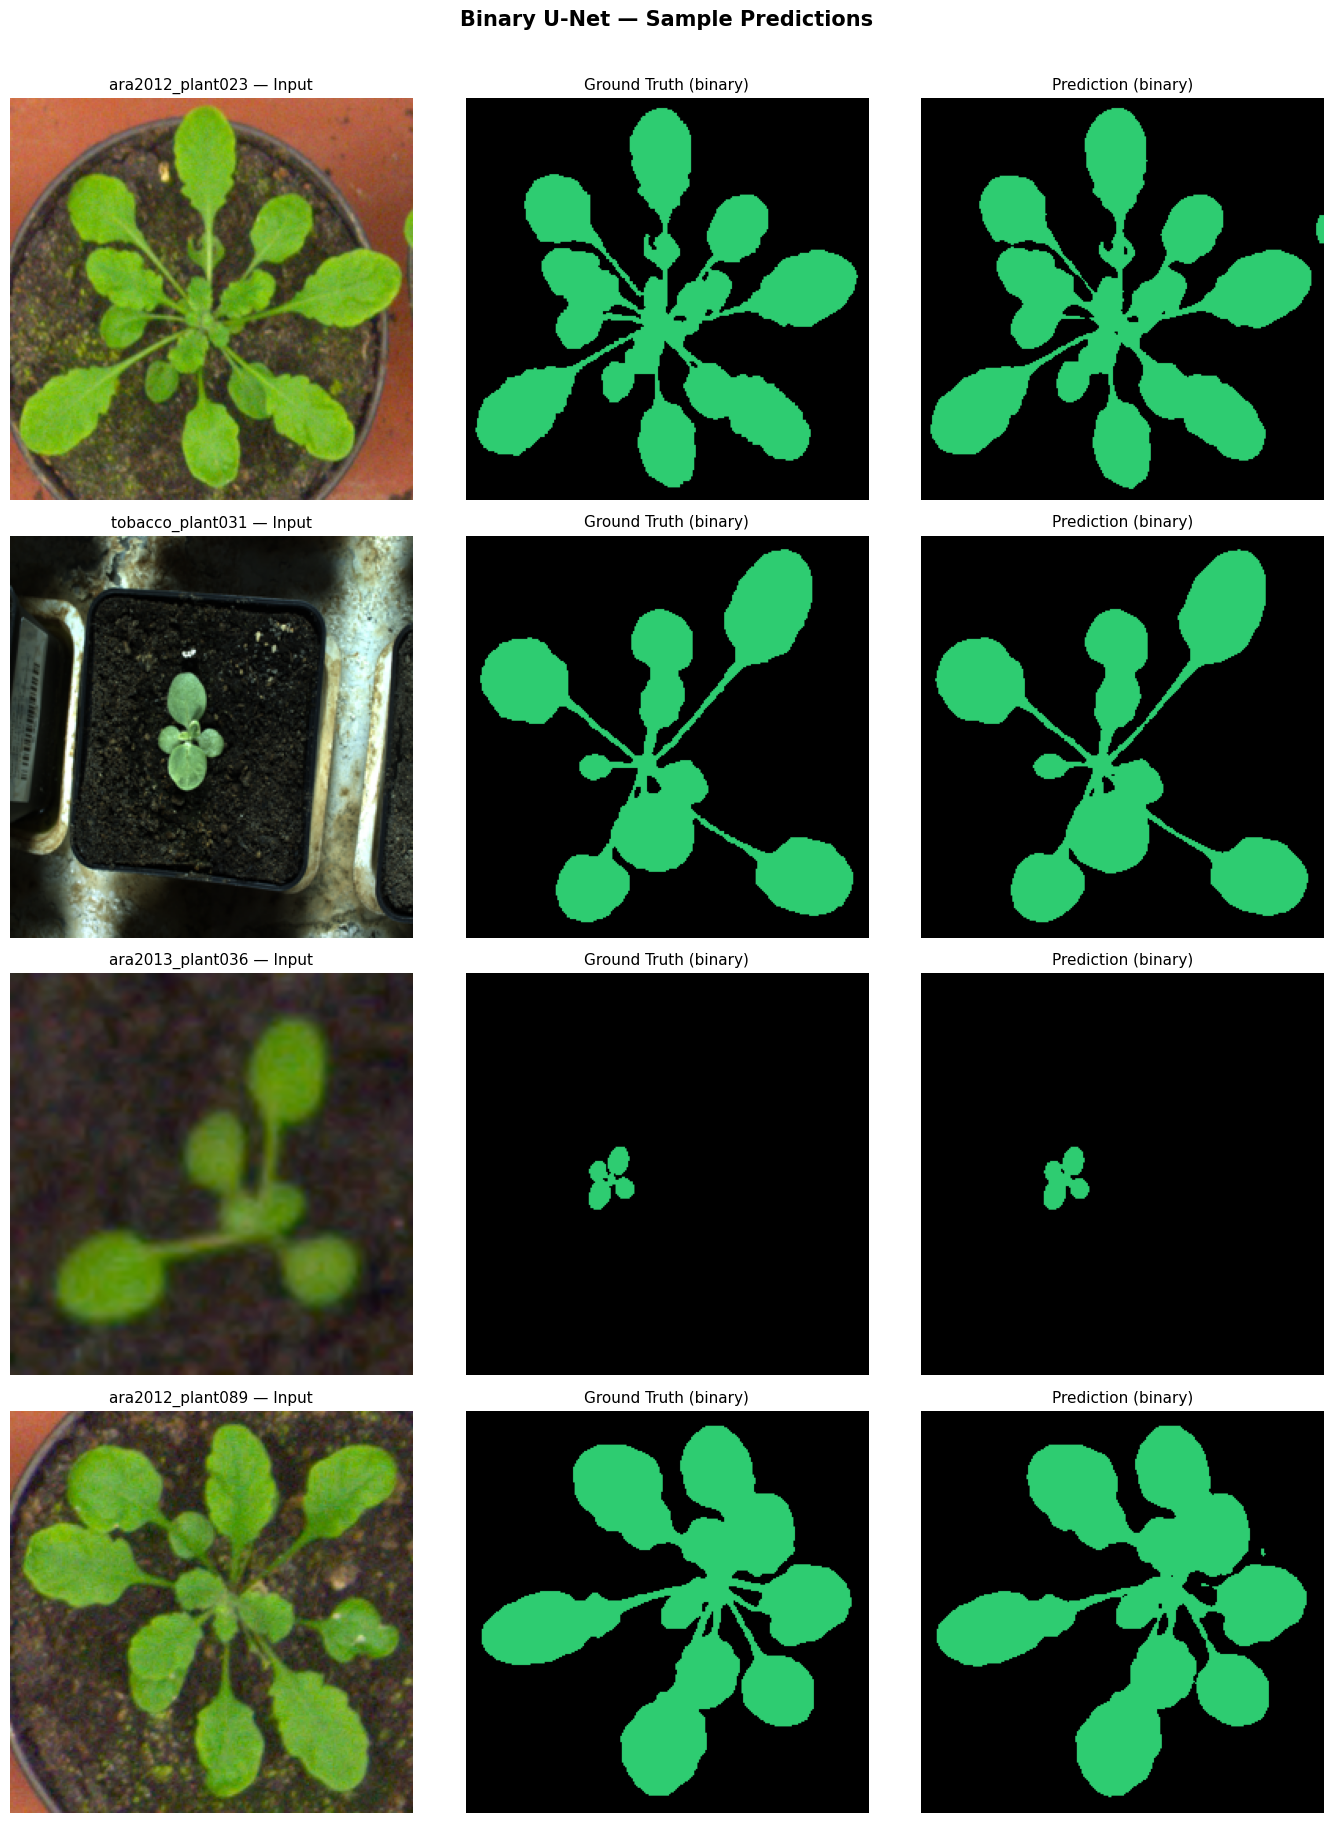

In [14]:
def color_mask(binary_mask):
    """binary_mask: (H,W) in {0,1} → RGB overlay"""
    h, w = binary_mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    out[binary_mask == 1] = [46, 204, 113]  # hijau
    return out

model.eval()
fig, axes = plt.subplots(4, 3, figsize=(14, 18))

for i, batch in enumerate(val_loader):
    if i >= 4: break
    imgs = batch['image'].to(device, dtype=torch.float32)
    names = batch['name']
    
    with torch.no_grad():
        pred = model(imgs).argmax(dim=1).cpu().numpy()
    true = batch['mask'].numpy()
    
    for j in range(min(imgs.shape[0], 1)):
        img = imgs[j].cpu().permute(1,2,0).numpy()
        idx = i  # use sample index
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f'{names[j]} — Input', fontsize=11)
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(color_mask(true[idx]))
        axes[idx, 1].set_title('Ground Truth (binary)', fontsize=11)
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(color_mask(pred[idx]))
        axes[idx, 2].set_title('Prediction (binary)', fontsize=11)
        axes[idx, 2].axis('off')

plt.suptitle('Binary U-Net — Sample Predictions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('binary_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Stage 2 — Leaf Separation (Watershed)

Dari binary mask, gunakan **Distance Transform + Watershed** untuk memisahkan daun yang saling tumpuk.

Alur:
```
Binary Mask → Distance Transform → Threshold → 
  Connected Components (markers) → Watershed → Daun terpisah
```

In [15]:
import cv2
from scipy import ndimage as ndi

def watershed_separate(binary_mask, min_dist=10):
    """
    Pisah daun tumpang tindih dari binary mask.
    
    Args:
        binary_mask: np.array (H,W) in {0,1}
        min_dist: jarak minimal antar pusat daun
    Returns:
        labels: np.array (H,W) — 0 = bg, 1..N = daun ke-N
    """
    # Pastikan uint8
    mask = (binary_mask * 255).astype(np.uint8)
    
    # Distance transform
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    dist_norm = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Threshold dapatkan marker
    _, sure_fg = cv2.threshold(dist_norm, 0.4 * dist_norm.max(), 255, 0)
    sure_fg = sure_fg.astype(np.uint8)
    
    # Connected components sebagai marker awal
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1  # Watershed: 0 = unknown
    
    # Tandai background pasti
    kernel = np.ones((3,3), np.uint8)
    sure_bg = cv2.dilate(mask, kernel, iterations=3)
    markers[sure_bg == 0] = 0
    
    # Watershed
    rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(rgb, markers)
    
    return markers  # 0 = bg, 1..N = leaf instances


def watershed_colormap(labels):
    """labels (H,W) → RGB untuk visualisasi"""
    h, w = labels.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    np.random.seed(0)
    n = labels.max()
    colors = np.random.randint(50, 255, size=(n+1, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]
    for i in range(1, n+1):
        out[labels == i] = colors[i]
    return out

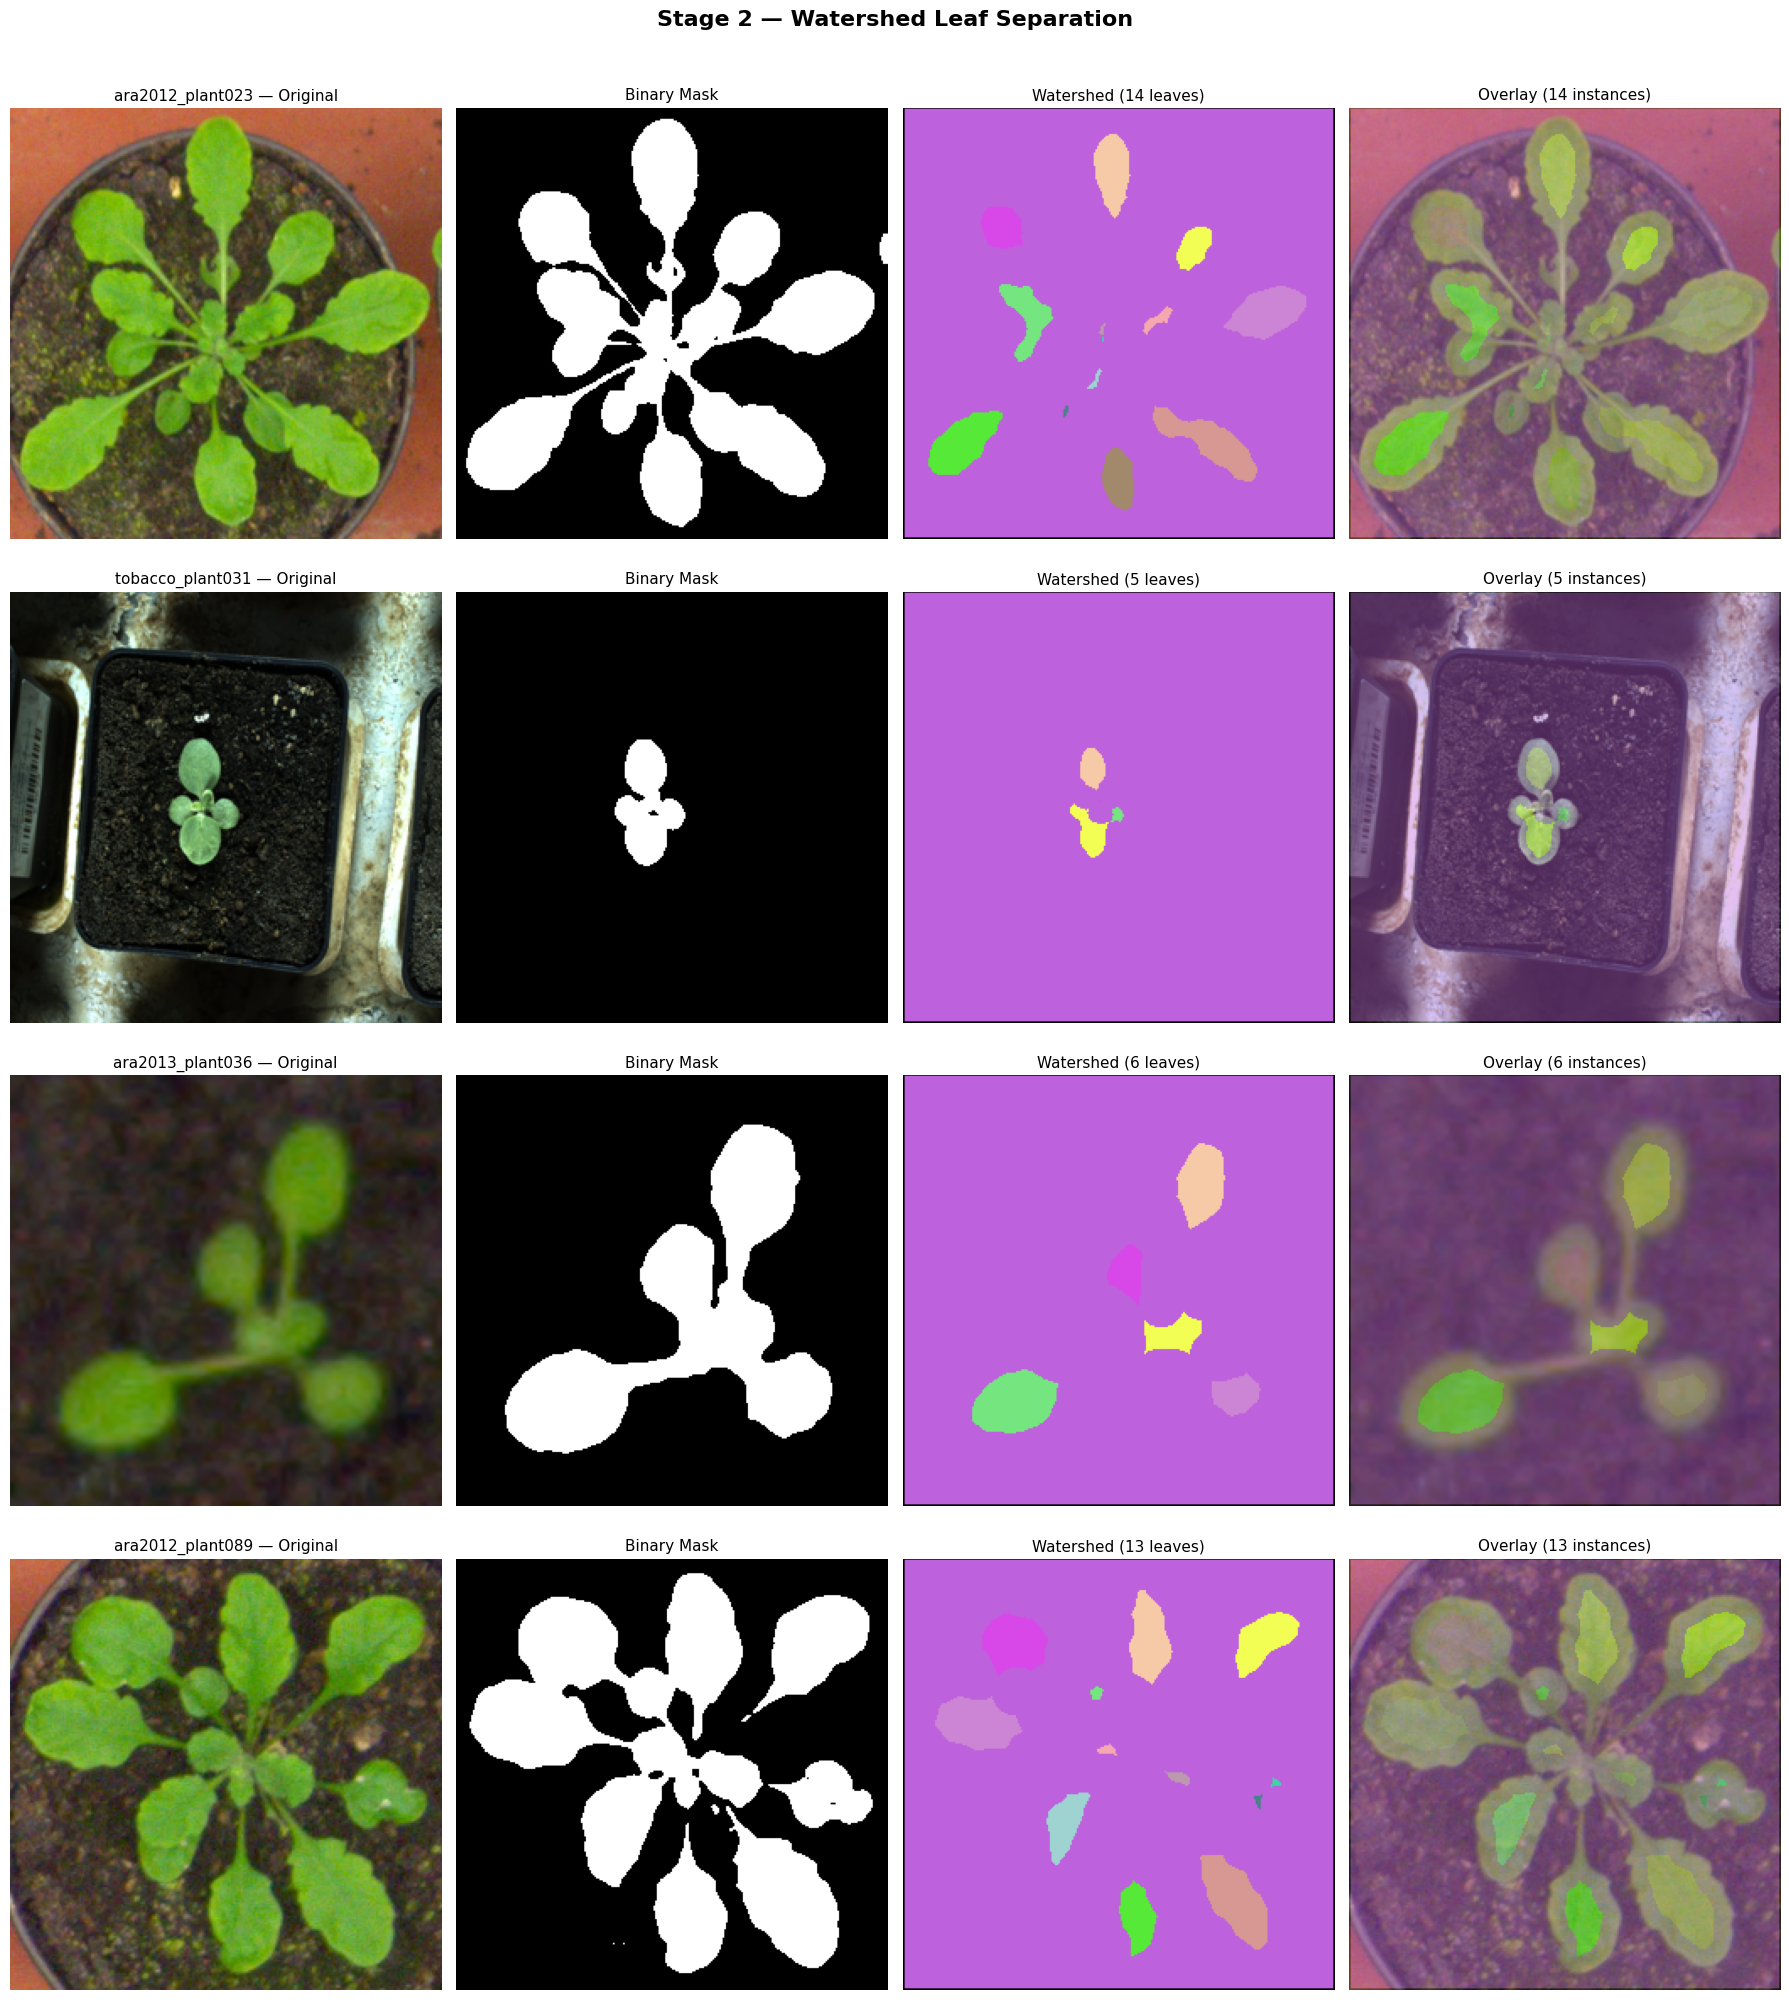


Watershed berhasil memisahkan daun yang saling tumpuk!


In [16]:
# Demo watershed pada beberapa sampel
model.eval()

fig, axes = plt.subplots(4, 4, figsize=(18, 20))

for i, batch in enumerate(val_loader):
    if i >= 4: break
    imgs = batch['image'].to(device, dtype=torch.float32)
    names = batch['name']

    with torch.no_grad():
        pred = model(imgs).argmax(dim=1).cpu().numpy()

    binary = pred[0]

    # Upsample prediksi ke 256x256 dulu untuk visual konsisten
    binary_full = cv2.resize(binary.astype(np.uint8), (256, 256), interpolation=cv2.INTER_NEAREST)

    # Watershed
    labels = watershed_separate(binary_full)
    n_leaves = labels.max()

    # Original image — resize ke 256x256 agar cocok dengan overlay
    orig = Image.open(f'data/imgs/{names[0]}.png').convert('RGB').resize((256, 256))

    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f'{names[0]} — Original', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(binary_full, cmap='gray')
    axes[i, 1].set_title('Binary Mask', fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(watershed_colormap(labels))
    axes[i, 2].set_title(f'Watershed ({n_leaves} leaves)', fontsize=11)
    axes[i, 2].axis('off')

    # Overlay — orig dan colored sudah sama ukuran 256x256
    overlay = np.array(orig).copy()
    colored = watershed_colormap(labels)
    overlay = cv2.addWeighted(overlay, 0.6, colored, 0.4, 0)
    axes[i, 3].imshow(overlay)
    axes[i, 3].set_title(f'Overlay ({n_leaves} instances)', fontsize=11)
    axes[i, 3].axis('off')

plt.suptitle('Stage 2 — Watershed Leaf Separation', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('watershed_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nWatershed berhasil memisahkan daun yang saling tumpuk!')

---
## Summary

### Stage 1 — Binary Segmentation
| Metrik | Nilai |
|---|---|
| IoU | (lihat output cell 7) |
| Dice | (lihat output cell 7) |

### Stage 2 — Watershed Separation
| Sampel | Daun terdeteksi |
|---|---|
| ... | (lihat output cell 11) |

**Kesimpulan:**
- Binary U-Net mengatasi masalah class imbalance (22 class → 2 class)
- Watershed memisah daun tumpang tindih dari mask binary
- Model siap ditingkatkan ke Enhanced U-Net di iterasi berikutnya